# create the samples for each major category for latent vector dataset

In [1]:
import os
main_attack_categories = [

"Malware",
"DoS_DDoS",
"Web_Attack",
"Reconnaissance",
"Brute_Force",
"Spoofing_MITM",
"Exploitation",
"Infiltration",
"Generic"
]
attack_hierarchy = {
   

    "Malware": [
        "Backdoor_Malware.csv",
        "Bot.csv",
        "Worms.csv",
        "Shellcode.csv",
        "Mirai-greeth_flood.csv",
        "Mirai-greip_flood.csv",
        "Mirai-udpplain.csv"
    ],

    "DoS_DDoS": [
        "DDoS.csv",
        "DDoS-ACK_Fragmentation.csv",
        "DDoS-ICMP_Flood.csv",
        "DDoS-ICMP_Fragmentation.csv",
        "DDoS-PSHACK_Flood.csv",
        "DDoS-RSTFINFlood.csv",
        "DDoS-SlowLoris.csv",
        "DDoS-SynonymousIP_Flood.csv",
        "DDoS-SYN_Flood.csv",
        "DDoS-TCP_Flood.csv",
        "DDoS-UDP_Flood.csv",
        "DDoS-UDP_Fragmentation.csv",
        "DoS_GoldenEye.csv",
        "DoS_Hulk.csv",
        "DoS_Slowhttptest.csv",
        "DoS_slowloris.csv",
        "DrDoS_DNS.csv",
        "DrDoS_LDAP.csv",
        "DrDoS_MSSQL.csv",
        "DrDoS_NetBIOS.csv",
        "DrDoS_NTP.csv",
        "DrDoS_SNMP.csv"
    ],

    "Web_Attack": [
        "BrowserHijacking.csv",
        "CommandInjection.csv",
        "SqlInjection.csv",
        "XSS.csv",
        "Web_Brute_Force.csv",
        "Web_Sql_Injection.csv",
        "Web_XSS.csv"
    ],

    "Reconnaissance": [
        "PortScan.csv",
        "Recon-HostDiscovery.csv",
        "Recon-PortScan.csv"
    ],

    "Brute_Force": [
        "FTP-Patator.csv",
        "SSH-Patator.csv"
    ],

    "Spoofing_MITM": [
        "DNS_Spoofing.csv",
        "MITM-ArpSpoofing.csv"
    ],

    "Exploitation": [
        "Exploits.csv",
        "Heartbleed.csv"
    ],

    "Infiltration": [
        "Infiltration.csv"
    ],

    "Generic": [
        "Fuzzers.csv",
        "Generic.csv",
        "TFTP.csv"
    ]
}

import pandas as pd


folder = 'attacks/'
df_list = []

# we need 50 examples of each main attack category
for mcat in main_attack_categories:
    files = attack_hierarchy[mcat]
    max_files = 30 // len(files)
    print(f"{mcat}: {max_files} rows per file")
    
    df_temp = []
    for fi in files:
        f_path = os.path.join(folder, fi)
        df = pd.read_csv(f_path)
        df_temp.append(df[0:max_files])  # Take max_files rows from each
    
    if len(df_temp) > 0:
        # Concatenate all DataFrames and reset index
        combined_df = pd.concat(df_temp, ignore_index=True)
        df_list.append((mcat, combined_df))

# Check results
for mcat, df in df_list:
    print(f"{mcat}: {df.shape}")


  


Malware: 4 rows per file
DoS_DDoS: 1 rows per file
Web_Attack: 4 rows per file
Reconnaissance: 10 rows per file
Brute_Force: 15 rows per file
Spoofing_MITM: 15 rows per file
Exploitation: 15 rows per file
Infiltration: 30 rows per file
Generic: 10 rows per file
Malware: (28, 89)
DoS_DDoS: (22, 89)
Web_Attack: (28, 89)
Reconnaissance: (30, 89)
Brute_Force: (30, 89)
Spoofing_MITM: (30, 89)
Exploitation: (30, 89)
Infiltration: (30, 89)
Generic: (30, 89)


Volumetric_UDP_ICMP: (1998, 64)
TCP_Protocol_Attack: (1998, 64)
Application_Layer_DoS: (1381, 64)
Reflection_DRDoS: (1998, 64)
Web_Infiltration: (1609, 64)
Brute_Force_Credentials: (2000, 64)
Running t-SNE... (this may take a minute)
[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 10984 samples in 0.001s...


c:\Users\youss\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 10984 samples in 0.343s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10984
[t-SNE] Computed conditional probabilities for sample 2000 / 10984
[t-SNE] Computed conditional probabilities for sample 3000 / 10984
[t-SNE] Computed conditional probabilities for sample 4000 / 10984
[t-SNE] Computed conditional probabilities for sample 5000 / 10984
[t-SNE] Computed conditional probabilities for sample 6000 / 10984
[t-SNE] Computed conditional probabilities for sample 7000 / 10984
[t-SNE] Computed conditional probabilities for sample 8000 / 10984
[t-SNE] Computed conditional probabilities for sample 9000 / 10984
[t-SNE] Computed conditional probabilities for sample 10000 / 10984
[t-SNE] Computed conditional probabilities for sample 10984 / 10984
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 81.533974
[t-SNE] KL divergence after 1000 iterations: 0.963072


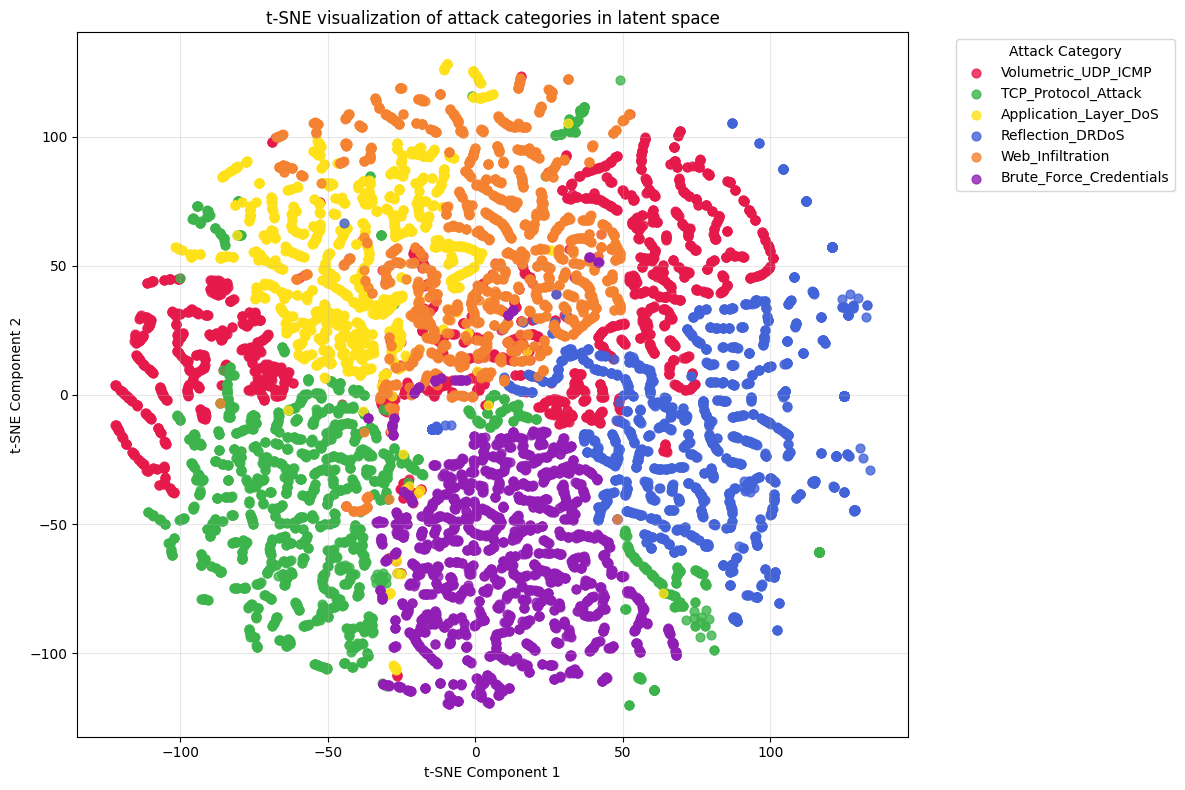

In [ ]:
import os
import pandas as pd
import torch
import torch.nn as nn
import joblib
import numpy as np
from scipy.spatial.distance import mahalanobis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


class ImprovedAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(ImprovedAutoencoder, self).__init__()
        bottleneck_dim = 4#max(8, input_dim // 6)

        self.encoder = nn.Sequential(
            nn.Linear(88, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(16, 16)
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(512, 88)

        )


    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


# ==========================
# Load Model and Scaler
# ==========================
model_path = r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\dl_ids\nfstream\mlp_best_numeric_autoencoder.pth"
autoencoder = ImprovedAutoencoder(input_dim=88)
autoencoder.load_state_dict(torch.load(model_path, weights_only=True))
autoencoder.eval()

scaler_path = r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\dl_ids\nfstream\#base_MLP_scaler.pkl"
scaler = joblib.load(scaler_path)

vector_dataset_of_attacks = {}

for mcat, df in df_list:
    # Drop label column and scale
    df_numeric = df.drop(columns=['label'], errors='ignore')
    df_scaled = scaler.transform(df_numeric)
    
    # Encode to latent space
    with torch.no_grad():
        latent_vector = autoencoder.encoder(
            torch.tensor(df_scaled, dtype=torch.float32)
        ).detach().numpy()
    
    print(f"{mcat}: {latent_vector.shape}")
    vector_dataset_of_attacks[mcat] = latent_vector
# Applying PCA function on training
# and testing set of X component
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Combine all latent vectors
all_latents = np.vstack(list(vector_dataset_of_attacks.values()))
all_labels = []
for mcat in vector_dataset_of_attacks:
    all_labels += [mcat] * len(vector_dataset_of_attacks[mcat])
all_labels = np.array(all_labels)

# Apply t-SNE
print("Running t-SNE... (this may take a minute)")
tsne = TSNE(
    n_components=2,
    perplexity=5,        # Try values between 5-50 depending on dataset size
    n_iter=1000,       # Number of iterations
    random_state=42,      # For reproducibility
    verbose=1             # Show progress
)
latent_2d = tsne.fit_transform(all_latents)

# Plot with legend
# Define a list of strong, distinct colors
colors = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8",
    "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff",
    "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#808080"
]

plt.figure(figsize=(12, 8))
for i, mcat in enumerate(vector_dataset_of_attacks):
    idx = all_labels == mcat
    plt.scatter(
        latent_2d[idx, 0],
        latent_2d[idx, 1],
        label=mcat,
        s=40,
        alpha=0.8,
        color=colors[i % len(colors)]  # cycle colors if more categories than colors
    )

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE visualization of attack categories in latent space')
plt.legend(title="Attack Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Manahlobis distance based labeling


Testing with 10 samples per category (PCA to 64D)

Accuracy: 81.17% | F1-Macro: 0.7573 | F1-Weighted: 0.8242

Testing with 20 samples per category (PCA to 64D)

Accuracy: 82.15% | F1-Macro: 0.7741 | F1-Weighted: 0.8225

OVERALL METRICS
Accuracy:            0.8215 (82.15%)
F1-Score (Macro):    0.7741
F1-Score (Weighted): 0.8225
Total Samples:       121078
Correct:             99464
Incorrect:           21614

Classification Report - Mahalanobis Distance

                         precision    recall  f1-score   support

    Volumetric_UDP_ICMP       0.99      0.80      0.88     28861
    TCP_Protocol_Attack       0.69      0.99      0.81     30000
  Application_Layer_DoS       0.75      0.78      0.76     16277
       Reflection_DRDoS       1.00      0.85      0.92     30000
       Web_Infiltration       0.48      0.38      0.43      8988
Brute_Force_Credentials       1.00      0.72      0.84      6952

               accuracy                           0.82    121078
              macro

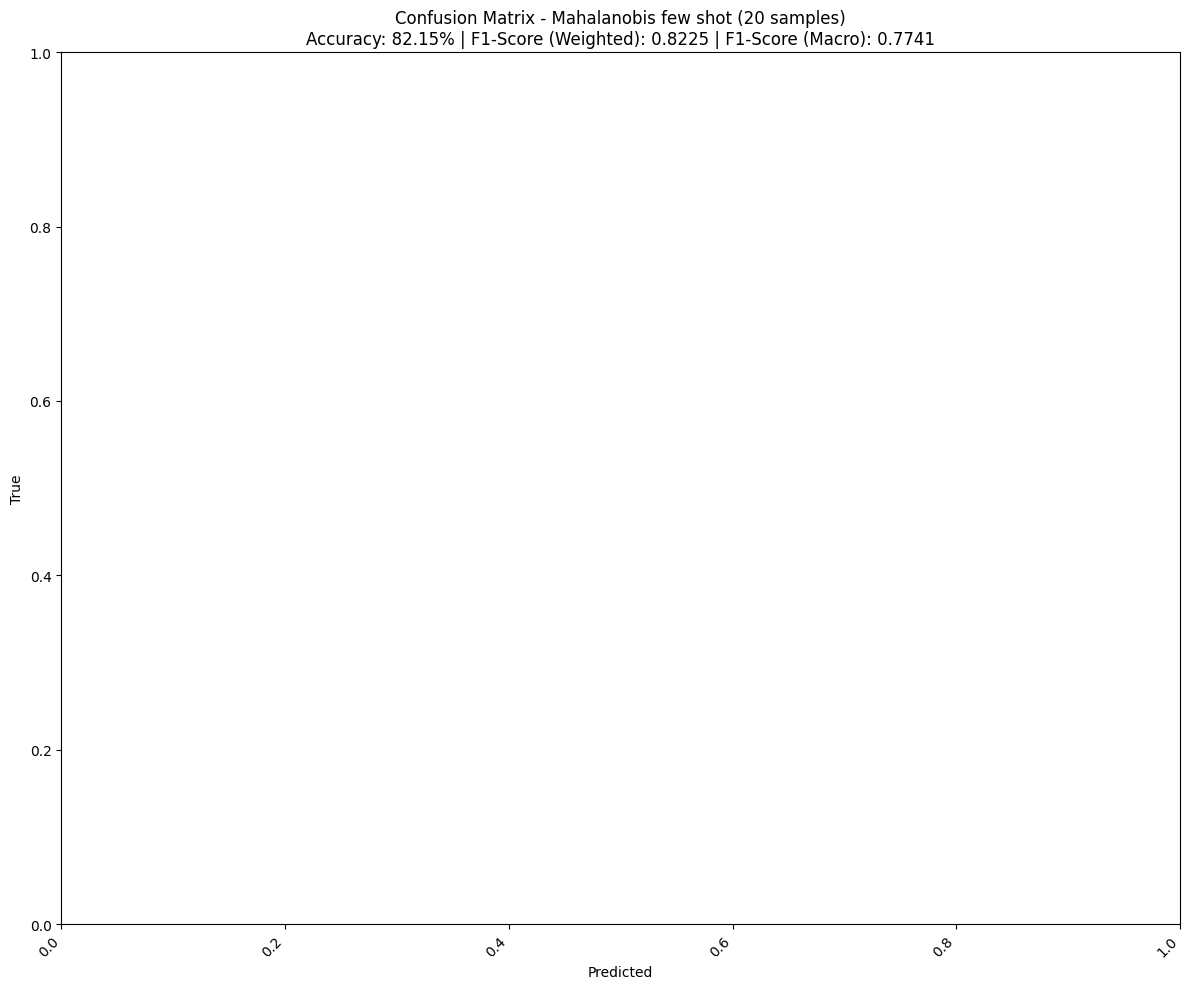

In [3]:
import os
import pandas as pd
import torch
import torch.nn as nn
import joblib
import numpy as np
from scipy.spatial.distance import mahalanobis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

main_attack_categories = [
    "Volumetric_UDP_ICMP",
    "TCP_Protocol_Attack",
    "Application_Layer_DoS",
    "Reflection_DRDoS",
    "Web_Infiltration",
    "Brute_Force_Credentials"
]

attack_hierarchy = {
    # High-volume, stateless blasting
    "Volumetric_UDP_ICMP": [
        "DDoS-UDP_Flood.csv", "DDoS-ICMP_Flood.csv", "DDoS-UDP_Fragmentation.csv", 
        "DDoS-ICMP_Fragmentation.csv", "Mirai-udpplain.csv", "Generic.csv"
    ],
    
    # TCP State machine abuse
    "TCP_Protocol_Attack": [
        "DDoS-SYN_Flood.csv", "DDoS-TCP_Flood.csv", "DDoS-ACK_Fragmentation.csv", 
        "DDoS-PSHACK_Flood.csv", "DDoS-RSTFINFlood.csv", "DDoS-SynonymousIP_Flood.csv"
    ],

    # Resource exhaustion via slow/complex requests
    "Application_Layer_DoS": [
        "DoS_GoldenEye.csv", "DoS_Hulk.csv", "DoS_Slowhttptest.csv", 
        "DoS_slowloris.csv", "DDoS-SlowLoris.csv", "Bot.csv"
    ],

    # Your current high-performers (keep them separate or grouped)
    "Reflection_DRDoS": [
        "DrDoS_DNS.csv", "DrDoS_LDAP.csv", "DrDoS_MSSQL.csv", 
        "DrDoS_NetBIOS.csv", "DrDoS_NTP.csv", "DrDoS_SNMP.csv"
    ],

    "Web_Infiltration": [
        "SqlInjection.csv", "XSS.csv", "Web_Brute_Force.csv", "Web_Sql_Injection.csv", 
        "Web_XSS.csv", "CommandInjection.csv", "BrowserHijacking.csv", "Infiltration.csv"
    ],

    "Brute_Force_Credentials": [
        "FTP-Patator.csv", "SSH-Patator.csv"
    ]
}



class ImprovedAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(ImprovedAutoencoder, self).__init__()
        bottleneck_dim = 4#max(8, input_dim // 6)

        self.encoder = nn.Sequential(
            nn.Linear(88, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(16, 16)
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(32, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(512, 88)

        )


    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


# ==========================
# Load Model and Scaler
# ==========================
model_path = r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\dl_ids\nfstream\mlp_best_numeric_autoencoder.pth"
autoencoder = ImprovedAutoencoder(input_dim=88)
autoencoder.load_state_dict(torch.load(model_path, weights_only=True))
autoencoder.eval()

scaler_path = r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\dl_ids\nfstream\#base_MLP_scaler.pkl"
scaler = joblib.load(scaler_path)

filename_to_category = {}
for category, files in attack_hierarchy.items():
    for filename in files:
        filename_to_category[filename] = category

attack_folder = r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\dl_ids\experiments_pca\attacks"

# Test with different sample sizes and PCA dimensions
SAMPLE_SIZES = [10,20]
PCA_DIM = 64

results_summary = []

for SAMPLES_PER_CATEGORY in SAMPLE_SIZES:
    print(f"\n{'='*70}")
    print(f"Testing with {SAMPLES_PER_CATEGORY} samples per category (PCA to {PCA_DIM}D)")
    print(f"{'='*70}\n")
    
    folder = 'attacks/'
    df_list = []

    for mcat in main_attack_categories:
        files = attack_hierarchy[mcat]
        max_files = max(1, SAMPLES_PER_CATEGORY // len(files))
        
        df_temp = []
        for fi in files:
            f_path = os.path.join(folder, fi)
            df = pd.read_csv(f_path)
            df_temp.append(df[0:max_files])
        
        if len(df_temp) > 0:
            combined_df = pd.concat(df_temp, ignore_index=True)
            df_list.append((mcat, combined_df))

    # Collect all latent vectors first to fit PCA
    all_latent = []
    all_labels = []
    
    for mcat, df in df_list:
        df_numeric = df.drop(columns=['label'], errors='ignore')
        df_scaled = scaler.transform(df_numeric)
        
        with torch.no_grad():
            latent = autoencoder.encoder(torch.tensor(df_scaled, dtype=torch.float32)).detach().numpy()
        
        all_latent.append(latent)
        all_labels.extend([mcat] * len(latent))
    
    all_latent = np.vstack(all_latent)
    
    # Fit PCA on all training latent vectors
   
    all_latent_pca = all_latent
    
   
    
    # Split back into categories and compute stats
    category_stats = {}
    start_idx = 0
    
    for mcat, df in df_list:
        n_samples = len(df)
        latent_pca = all_latent_pca[start_idx:start_idx + n_samples]
        start_idx += n_samples
        
        mean = latent_pca.mean(axis=0)
        cov = np.cov(latent_pca.T)
        cov_inv = np.linalg.pinv(cov + np.eye(cov.shape[0]) *1e-06)
        
        category_stats[mcat] = {'mean': mean, 'cov_inv': cov_inv}

    y_true = []
    y_pred = []

    for attack_file in os.listdir(attack_folder):
        if not attack_file.endswith('.csv'):
            continue
        
        ground_truth = filename_to_category.get(attack_file)
        if not ground_truth:
            continue
        
        df = pd.read_csv(os.path.join(attack_folder, attack_file))
        df_scaled = scaler.transform(df.drop(columns=['label'], errors='ignore'))
        
        with torch.no_grad():
            latent = autoencoder.encoder(torch.tensor(df_scaled, dtype=torch.float32)).detach().numpy()
        
        # Apply PCA transform
        latent_pca =latent
        
        for sample in latent_pca:
            distances = {}
            for mcat in main_attack_categories:
                if mcat in category_stats:
                    mean = category_stats[mcat]['mean']
                    cov_inv = category_stats[mcat]['cov_inv']
                    
                    try:
                        d = mahalanobis(sample, mean, cov_inv)
                    except:
                        d = np.linalg.norm(sample - mean)
                    
                    distances[mcat] = d
            
            predicted = min(distances.items(), key=lambda x: x[1])[0]
            
            y_true.append(ground_truth)
            y_pred.append(predicted)

    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, labels=main_attack_categories, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, labels=main_attack_categories, average='weighted', zero_division=0)

    print(f"Accuracy: {accuracy*100:.2f}% | F1-Macro: {f1_macro:.4f} | F1-Weighted: {f1_weighted:.4f}")
    
    results_summary.append({
        'samples': SAMPLES_PER_CATEGORY,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    })
# ==========================
# Calculate Metrics
# ==========================
accuracy = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, labels=main_attack_categories, average='macro', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, labels=main_attack_categories, average='weighted', zero_division=0)

print(f"\n{'='*60}")
print("OVERALL METRICS")
print(f"{'='*60}")
print(f"Accuracy:            {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"F1-Score (Macro):    {f1_macro:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")
print(f"Total Samples:       {len(y_true)}")
print(f"Correct:             {sum([1 for t, p in zip(y_true, y_pred) if t == p])}")
print(f"Incorrect:           {sum([1 for t, p in zip(y_true, y_pred) if t != p])}")

# ==========================
# Classification Report
# ==========================
print(f"\n{'='*60}")
print("Classification Report - Mahalanobis Distance")
print(f"{'='*60}\n")
print(classification_report(y_true, y_pred, labels=main_attack_categories, zero_division=0))

# ==========================
# Confusion Matrix
# ==========================
cm = confusion_matrix(y_true, y_pred, labels=main_attack_categories)

print(f"\n{'='*60}")
print("Confusion Matrix")
print(f"{'='*60}\n")

cm_df = pd.DataFrame(cm, index=main_attack_categories, columns=main_attack_categories)
print(cm_df)

# ==========================
# Plot Confusion Matrix
# ==========================
plt.figure(figsize=(12, 10))

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - Mahalanobis few shot (20 samples)\nAccuracy: {accuracy*100:.2f}% | F1-Score (Weighted): {f1_weighted:.4f} | F1-Score (Macro): {f1_macro:.4f}')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_mahalanobis_50samples.png', dpi=300, bbox_inches='tight')
print(f"\n{'='*70}")
print(f"SUMMARY (with PCA to {PCA_DIM}D)")
print(f"{'='*70}")
print(f"{'Samples':<10} {'Accuracy':<12} {'F1-Macro':<12} {'F1-Weighted':<12}")
print("-" * 70)
for r in results_summary:
    print(f"{r['samples']:<10} {r['accuracy']*100:>10.2f}% {r['f1_macro']:>11.4f} {r['f1_weighted']:>11.4f}")

In [4]:
category_stats[mcat] = {'mean': mean, 'cov_inv': cov_inv}
joblib.dump(category_stats, "prototypes.pkl")

['prototypes.pkl']

# hyperparameter testing for coveriance 

Step 1: Extracting training latent vectors...

Step 2: Starting Hyperparameter Search...


Dim: 32 | Reg: 1.0e-07 | Macro F1: 0.8680


Dim: 32 | Reg: 1.0e-06 | Macro F1: 0.8809


Dim: 32 | Reg: 1.0e-05 | Macro F1: 0.8791


Dim: 32 | Reg: 1.0e-04 | Macro F1: 0.8770


...

Dim: 48 | Reg: 1.0e-04 | Macro F1: 0.8778


Dim: 64 | Reg: 1.0e-07 | Macro F1: 0.8670


Dim: 64 | Reg: 1.0e-06 | Macro F1: 0.8830


Dim: 64 | Reg: 1.0e-05 | Macro F1: 0.8790


Dim: 64 | Reg: 1.0e-04 | Macro F1: 0.8764

BEST CONFIG: PCA 64D | Reg 1e-06 | F1 0.8830

Final Classification Report:
                         precision    recall  f1-score   support

    Volumetric_UDP_ICMP       0.94      0.84      0.89     12000
    TCP_Protocol_Attack       0.93      0.94      0.93     12000
  Application_Layer_DoS       0.79      0.93      0.85      7277
       Reflection_DRDoS       0.99      0.94      0.97     12000
       Web_Infiltration       0.75      0.73      0.74      7074
Brute_Force_Credentials       0.85      0.99      0.92      4000

               accuracy                           0.89     54351
              macro avg       0.88      0.90      0.88     54351
           weighted avg       0.90      0.89      0.89     54351



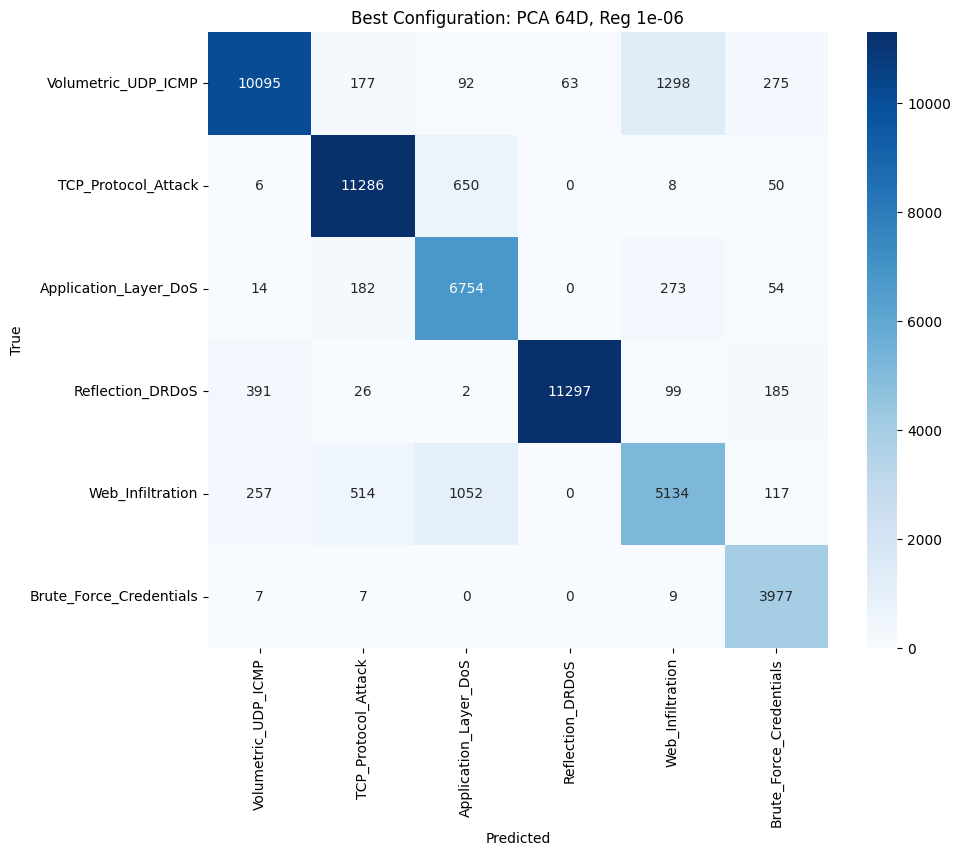

In [64]:
import os
import pandas as pd
import torch
import torch.nn as nn
import joblib
import numpy as np
import copy
from scipy.spatial.distance import mahalanobis
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================
# 1. Model & Scaler Loading
# ==========================
class ImprovedAutoencoder(nn.Module):
    def __init__(self, input_dim=88):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 64)
        )
    def forward(self, x): return self.encoder(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\dl_ids\experiments_pca\mlp_best_numeric_autoencoder.pth"
scaler_path = r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\dl_ids\experiments_pca\#base_MLP_scaler.pkl"
attack_folder = r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\dl_ids\experiments_pca\attacks"

autoencoder = ImprovedAutoencoder(input_dim=88).to(device)
autoencoder.load_state_dict(torch.load(model_path, map_location=device, weights_only=True), strict=False)
autoencoder.eval()
scaler = joblib.load(scaler_path)

# ==========================
# 2. Hierarchy Configuration
# ==========================
attack_hierarchy = {
    "Volumetric_UDP_ICMP": ["DDoS-UDP_Flood.csv", "DDoS-ICMP_Flood.csv", "DDoS-UDP_Fragmentation.csv", "DDoS-ICMP_Fragmentation.csv", "Mirai-udpplain.csv", "Generic.csv"],
    "TCP_Protocol_Attack": ["DDoS-SYN_Flood.csv", "DDoS-TCP_Flood.csv", "DDoS-ACK_Fragmentation.csv", "DDoS-PSHACK_Flood.csv", "DDoS-RSTFINFlood.csv", "DDoS-SynonymousIP_Flood.csv"],
    "Application_Layer_DoS": ["DoS_GoldenEye.csv", "DoS_Hulk.csv", "DoS_Slowhttptest.csv", "DoS_slowloris.csv", "DDoS-SlowLoris.csv", "Bot.csv"],
    "Reflection_DRDoS": ["DrDoS_DNS.csv", "DrDoS_LDAP.csv", "DrDoS_MSSQL.csv", "DrDoS_NetBIOS.csv", "DrDoS_NTP.csv", "DrDoS_SNMP.csv"],
    "Web_Infiltration": ["SqlInjection.csv", "XSS.csv", "Web_Brute_Force.csv", "Web_Sql_Injection.csv", "Web_XSS.csv", "CommandInjection.csv", "BrowserHijacking.csv", "Infiltration.csv"],
    "Brute_Force_Credentials": ["FTP-Patator.csv", "SSH-Patator.csv"]
}

filename_to_category = {f: cat for cat, files in attack_hierarchy.items() for f in files}
main_attack_categories = list(attack_hierarchy.keys())

# ==========================
# 3. Preparation & Search
# ==========================
SAMPLES_PER_CAT = 20
REG_VALS = [1e-7, 1e-6, 1e-5, 1e-4]
PCA_DIMS = [32, 48, 64] 

print("Step 1: Extracting training latent vectors...")
train_latents, train_labels = [], []
for mcat, files in attack_hierarchy.items():
    max_samples = max(1, SAMPLES_PER_CAT // len(files))
    for f in files:
        p = os.path.join(attack_folder, f)
        df = pd.read_csv(p).select_dtypes(include='number').iloc[:max_samples]
        with torch.no_grad():
            z = autoencoder.encoder(torch.tensor(scaler.transform(df), dtype=torch.float32).to(device)).cpu().numpy()
        train_latents.append(z)
        train_labels.extend([mcat] * len(z))

train_latents = np.vstack(train_latents)

best_f1, best_params = 0, {}

print("\nStep 2: Starting Hyperparameter Search...")
for dim in PCA_DIMS:
    pca_mod = PCA(n_components=dim) if dim < 64 else None
    z_train = pca_mod.fit_transform(train_latents) if pca_mod else train_latents

    for reg in REG_VALS:
        stats = {}
        for mcat in main_attack_categories:
            mask = np.array(train_labels) == mcat
            cat_z = z_train[mask]
            mean = cat_z.mean(axis=0)
            cov = np.cov(cat_z.T)
            cov_inv = np.linalg.pinv(cov + np.eye(cov.shape[0]) * reg)
            stats[mcat] = {'mean': mean, 'cov_inv': cov_inv}

        y_true, y_pred = [], []
        # tqdm progress bar for tracking
        for f_name, ground_truth in tqdm(filename_to_category.items(), desc=f"Testing D:{dim} R:{reg:.0e}", leave=False):
            p = os.path.join(attack_folder, f_name)
            df_full = pd.read_csv(p).select_dtypes(include='number')
            
            # SAFE SAMPLING: Take 2000 or the max available
            n_to_sample = min(len(df_full), 2000)
            df_sampled = df_full.sample(n=n_to_sample)
            
            with torch.no_grad():
                z_test = autoencoder.encoder(torch.tensor(scaler.transform(df_sampled), dtype=torch.float32).to(device)).cpu().numpy()
            if pca_mod: z_test = pca_mod.transform(z_test)
            
            for sample in z_test:
                dists = {c: mahalanobis(sample, s['mean'], s['cov_inv']) for c, s in stats.items()}
                y_pred.append(min(dists, key=dists.get))
                y_true.append(ground_truth)

        m_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        print(f"Dim: {dim} | Reg: {reg:.1e} | Macro F1: {m_f1:.4f}")

        if m_f1 > best_f1:
            best_f1 = m_f1
            best_params = {'dim': dim, 'reg': reg, 'stats': stats, 'pca': pca_mod, 'y_true': y_true, 'y_pred': y_pred}

# ==========================
# 4. Final Reporting
# ==========================
print(f"\n{'='*40}\nBEST CONFIG: PCA {best_params['dim']}D | Reg {best_params['reg']:.0e} | F1 {best_f1:.4f}\n{'='*40}")

print("\nFinal Classification Report:")
print(classification_report(best_params['y_true'], best_params['y_pred'], labels=main_attack_categories))

cm = confusion_matrix(best_params['y_true'], best_params['y_pred'], labels=main_attack_categories)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=main_attack_categories, yticklabels=main_attack_categories)
plt.title(f"Best Configuration: PCA {best_params['dim']}D, Reg {best_params['reg']:.0e}")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# detecting possible mismatch

Computing Main Category Centroids...
Auditing Sub-Files against Main Categories...


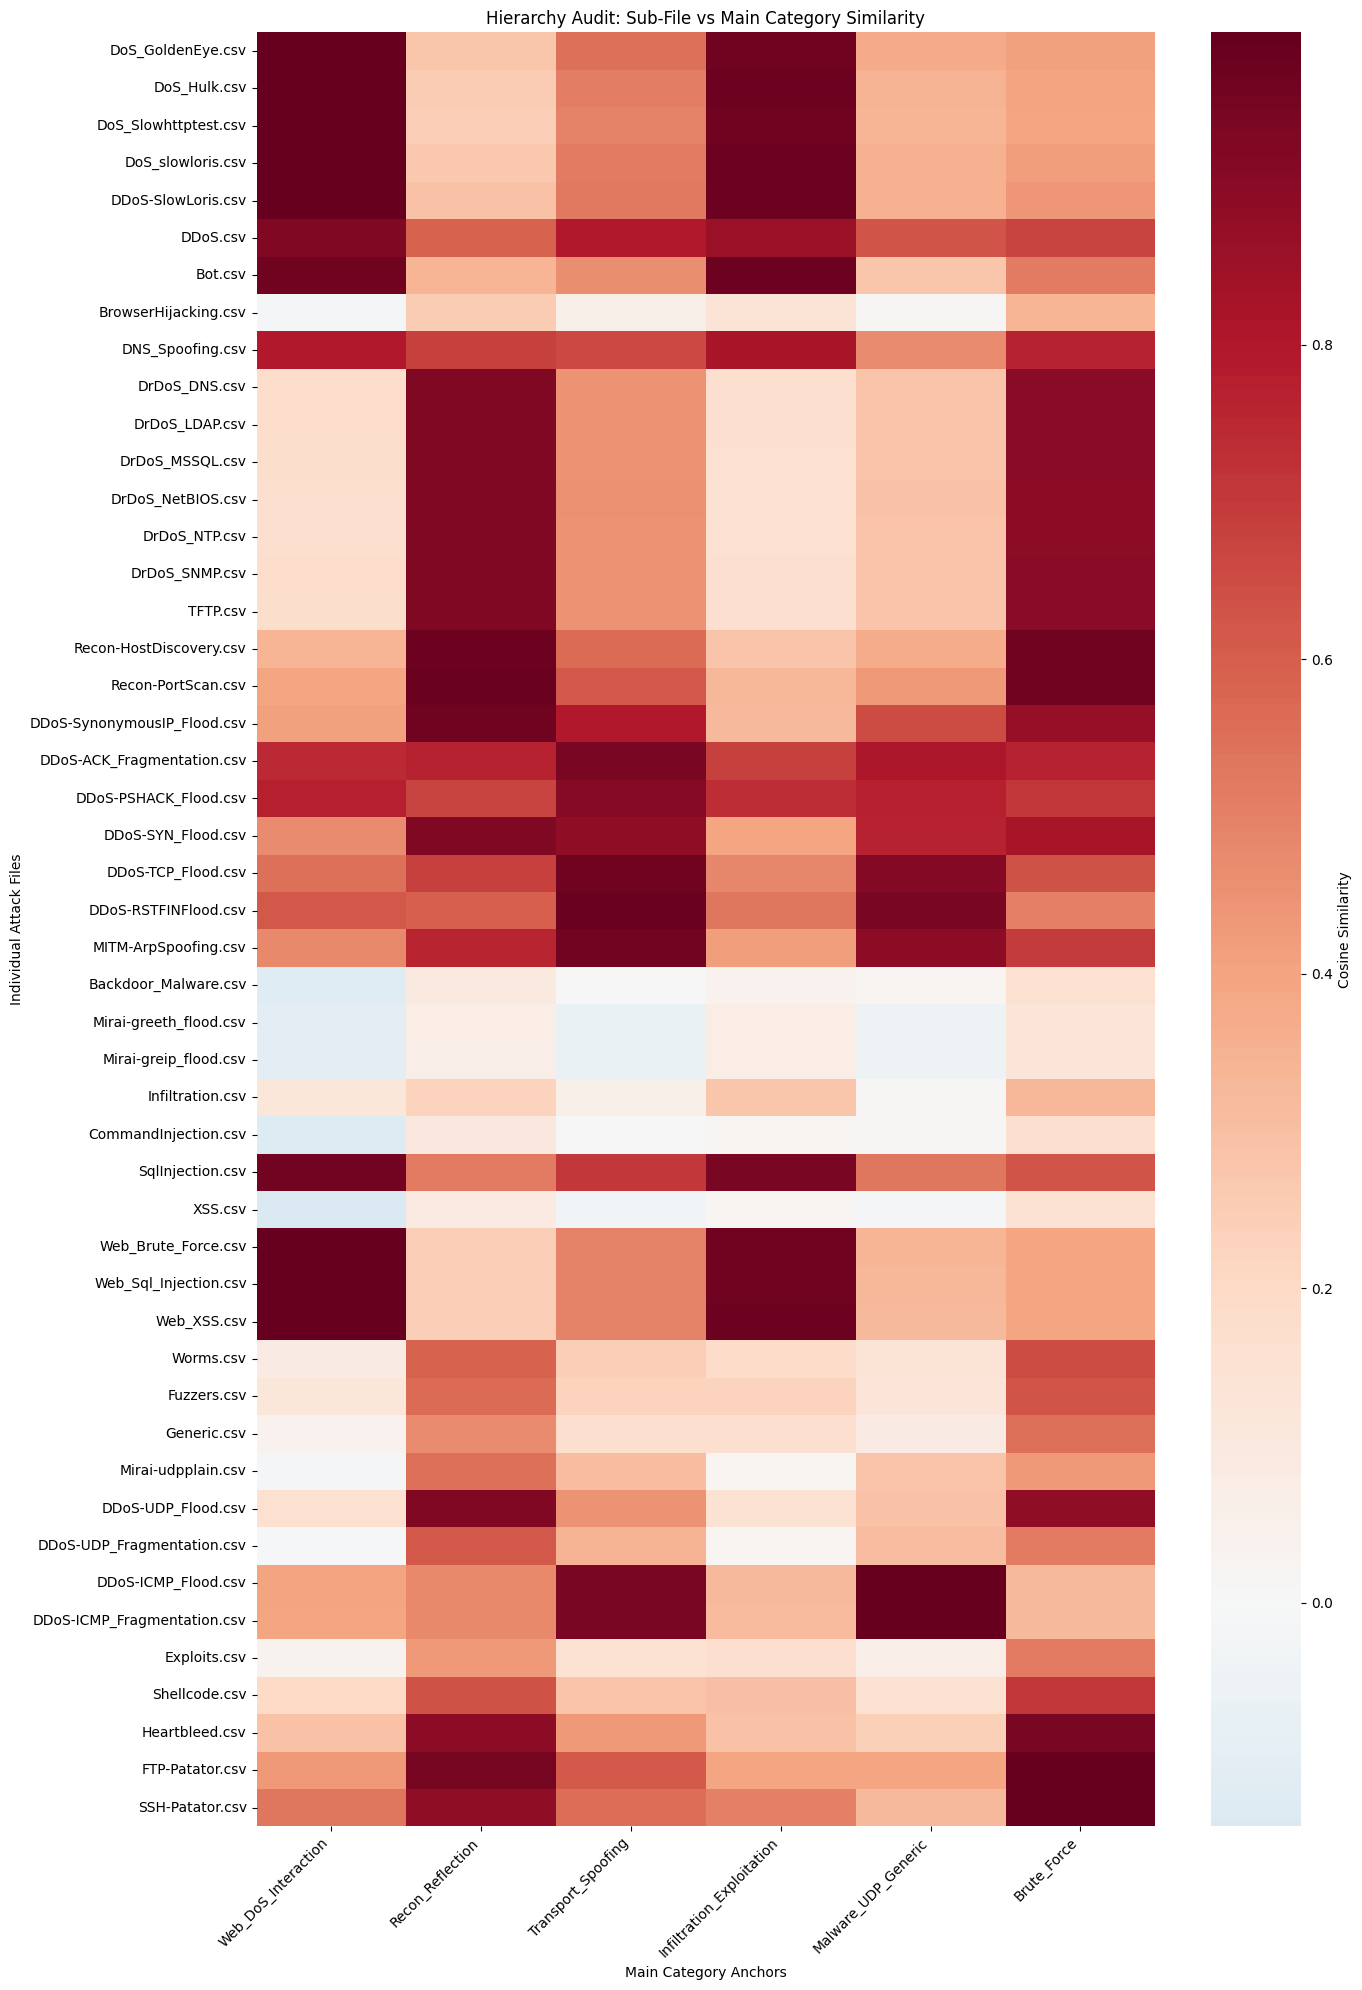


File Name                           | Labeled As      | Closest To      | Similarity
Bot.csv                             | Web_DoS_Interaction | Infiltration_Exploitation | 0.9718
BrowserHijacking.csv                | Web_DoS_Interaction | Brute_Force     | 0.3415
DNS_Spoofing.csv                    | Web_DoS_Interaction | Infiltration_Exploitation | 0.8226
DDoS-SYN_Flood.csv                  | Transport_Spoofing | Recon_Reflection | 0.9307
Backdoor_Malware.csv                | Infiltration_Exploitation | Brute_Force     | 0.1571
Mirai-greeth_flood.csv              | Infiltration_Exploitation | Brute_Force     | 0.1311
Mirai-greip_flood.csv               | Infiltration_Exploitation | Brute_Force     | 0.1305
Infiltration.csv                    | Infiltration_Exploitation | Brute_Force     | 0.3319
CommandInjection.csv                | Infiltration_Exploitation | Brute_Force     | 0.1666
SqlInjection.csv                    | Infiltration_Exploitation | Web_DoS_Interaction | 0.9591
XSS.

In [63]:
import os
import pandas as pd
import torch
import torch.nn as nn
import joblib
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================
# [PASTE YOUR ImprovedAutoencoder CLASS HERE]
# ==========================
class ImprovedAutoencoder(nn.Module):
    def __init__(self, input_dim=88):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 64)
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# ==========================
# CONFIG & HIERARCHY
# ==========================
main_attack_categories = [
    "Web_DoS_Interaction",
    "Recon_Reflection",
    "Transport_Spoofing",
    "Infiltration_Exploitation",
    "Malware_UDP_Generic",
    "Brute_Force"
]

attack_hierarchy = {

    # Web-layer abuse + application-layer DoS + bot-driven traffic
    "Web_DoS_Interaction": [
        "DoS_GoldenEye.csv",
        "DoS_Hulk.csv",
        "DoS_Slowhttptest.csv",
        "DoS_slowloris.csv",
        "DDoS-SlowLoris.csv",
        "DDoS.csv",
        "Bot.csv",
        "BrowserHijacking.csv",
        "DNS_Spoofing.csv"
    ],

    # Reflection-based amplification + probing behavior
    "Recon_Reflection": [
        "DrDoS_DNS.csv",
        "DrDoS_LDAP.csv",
        "DrDoS_MSSQL.csv",
        "DrDoS_NetBIOS.csv",
        "DrDoS_NTP.csv",
        "DrDoS_SNMP.csv",
        "TFTP.csv",
        "Recon-HostDiscovery.csv",
        "Recon-PortScan.csv",
        "DDoS-SynonymousIP_Flood.csv"
    ],

    # TCP flag abuse, fragmentation, and MITM-style spoofing
    "Transport_Spoofing": [
        "DDoS-ACK_Fragmentation.csv",
        "DDoS-PSHACK_Flood.csv",
        "DDoS-SYN_Flood.csv",
        "DDoS-TCP_Flood.csv",
        "DDoS-RSTFINFlood.csv",
        "MITM-ArpSpoofing.csv"
    ],

    # Initial access → exploitation → persistence
    "Infiltration_Exploitation": [
        "Backdoor_Malware.csv",
        "Mirai-greeth_flood.csv",
        "Mirai-greip_flood.csv",
        "Infiltration.csv",
        "CommandInjection.csv",
        "SqlInjection.csv",
        "XSS.csv",
        "Web_Brute_Force.csv",
        "Web_Sql_Injection.csv",
        "Web_XSS.csv"
    ],

    # Payload-driven, protocol-agnostic malicious behavior
    "Malware_UDP_Generic": [
        "Worms.csv",
        "Fuzzers.csv",
        "Generic.csv",
        "Mirai-udpplain.csv",
        "DDoS-UDP_Flood.csv",
        "DDoS-UDP_Fragmentation.csv",
        "DDoS-ICMP_Flood.csv",
        "DDoS-ICMP_Fragmentation.csv",
        "Exploits.csv",
        "Shellcode.csv",
        "Heartbleed.csv"
    ],

    # Credential guessing attacks (distinct behaviorally)
    "Brute_Force": [
        "FTP-Patator.csv",
        "SSH-Patator.csv"
    ]
}
# ==========================
# SETUP
# ==========================
model_path = r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\dl_ids\experiments_pca\mlp_best_numeric_autoencoder.pth"
autoencoder = ImprovedAutoencoder(input_dim=88)
autoencoder.load_state_dict(torch.load(model_path, weights_only=True))
autoencoder.eval()

scaler_path = r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\dl_ids\experiments_pca\#base_MLP_scaler.pkl"
scaler = joblib.load(scaler_path)

folder = r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\dl_ids\experiments_pca\attacks"

# ==========================
# STEP 1: Compute MAIN CATEGORY Centroids
# ==========================
print("Computing Main Category Centroids...")
main_centroids = {}
SAMPLES_PER_CATEGORY = 50

for mcat in main_attack_categories:
    files = attack_hierarchy.get(mcat, [])
    max_files = max(1, SAMPLES_PER_CATEGORY // len(files))
    
    df_temp = []
    for fi in files:
        f_path = os.path.join(folder, fi)
        if os.path.exists(f_path):
            df = pd.read_csv(f_path)
            df_temp.append(df[0:max_files])
    
    if len(df_temp) > 0:
        combined_df = pd.concat(df_temp, ignore_index=True)
        # Process
        df_num = combined_df.drop(columns=['label'], errors='ignore').fillna(0)
        df_scaled = scaler.transform(df_num)
        with torch.no_grad():
            latent = autoencoder.encoder(torch.tensor(df_scaled, dtype=torch.float32)).detach().numpy()
        
        # Calculate Centroid
        centroid = latent.mean(axis=0)
        main_centroids[mcat] = centroid

# ==========================
# STEP 2: Compute SUB-FILE Centroids & Compare
# ==========================
print("Auditing Sub-Files against Main Categories...")

similarity_data = []
row_labels = []

# List of files we want to check (flatten hierarchy)
all_files = []
file_to_true_parent = {}

for parent, children in attack_hierarchy.items():
    for child in children:
        all_files.append(child)
        file_to_true_parent[child] = parent

for filename in all_files:
    f_path = os.path.join(folder, filename)
    if not os.path.exists(f_path):
        continue

    # Load up to 50 samples of this specific file
    df = pd.read_csv(f_path)
    df = df.head(50)
    
    df_num = df.drop(columns=['label'], errors='ignore').fillna(0)
    if len(df_num) == 0: continue
    
    df_scaled = scaler.transform(df_num)
    with torch.no_grad():
        latent = autoencoder.encoder(torch.tensor(df_scaled, dtype=torch.float32)).detach().numpy()
    
    # File Centroid
    file_centroid = latent.mean(axis=0).reshape(1, -1)
    
    # Calculate Similarity to ALL Main Categories
    sims = []
    for mcat in main_attack_categories:
        main_cent = main_centroids[mcat].reshape(1, -1)
        sim = cosine_similarity(file_centroid, main_cent)[0][0]
        sims.append(sim)
    
    similarity_data.append(sims)
    row_labels.append(filename)

# ==========================
# STEP 3: Visualization & Report
# ==========================
similarity_matrix = np.array(similarity_data)

# Create DataFrame for plotting
sim_df = pd.DataFrame(similarity_matrix, index=row_labels, columns=main_attack_categories)

# Plot Heatmap
plt.figure(figsize=(14, 20))  # Tall plot to fit all files
sns.heatmap(sim_df, annot=False, cmap='RdBu_r', center=0, cbar_kws={'label': 'Cosine Similarity'})

plt.title('Hierarchy Audit: Sub-File vs Main Category Similarity')
plt.xlabel('Main Category Anchors')
plt.ylabel('Individual Attack Files')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('hierarchy_audit_heatmap.png', dpi=300)
plt.show()

# ==========================
# STEP 4: Print Mismatches
# ==========================
print(f"\n{'='*80}")
print(f"{'File Name':<35} | {'Labeled As':<15} | {'Closest To':<15} | {'Similarity'}")
print(f"{'='*80}")

for filename, sims in zip(row_labels, similarity_data):
    true_parent = file_to_true_parent[filename]
    
    # Find max similarity index
    best_idx = np.argmax(sims)
    best_match = main_attack_categories[best_idx]
    best_score = sims[best_idx]
    
    # Check if mismatch (and if the match is reasonably strong > 0.8)
    if best_match != true_parent:
        print(f"{filename:<35} | {true_parent:<15} | {best_match:<15} | {best_score:.4f}")

print(f"{'='*80}")

# greedy algorithm to find best

In [43]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import joblib
import copy
from scipy.spatial.distance import mahalanobis
from sklearn.metrics import f1_score
from tqdm import tqdm

# ==========================
# 1. YOUR ImprovedAutoencoder
# ==========================
class ImprovedAutoencoder(nn.Module):
    def __init__(self, input_dim=88):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 64)
        )
    def forward(self, x):
        return self.encoder(x)

# ==========================
# 2. Setup
# ==========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\dl_ids\experiments_pca\mlp_best_numeric_autoencoder.pth"
scaler_path = r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\dl_ids\experiments_pca\#base_MLP_scaler.pkl"
attack_folder = r"C:\Users\youss\Downloads\uni_stuff\grad_cs_part\dl_ids\experiments_pca\attacks"

autoencoder = ImprovedAutoencoder(input_dim=88).to(device)
autoencoder.load_state_dict(torch.load(model_path, map_location=device), strict=False)
autoencoder.eval()
scaler = joblib.load(scaler_path)

main_attack_categories = ["Web_DoS_Interaction", "Recon_Reflection", "Transport_Spoofing", "Infiltration_Exploitation", "Malware_UDP_Generic", "Brute_Force"]

# ==========================
# 3. Evaluation Logic (Strictly Macro F1)
# ==========================

def get_latent_stats(hierarchy):
    stats = {}
    for cat, files in hierarchy.items():
        all_z = []
        for f in files:
            p = os.path.join(attack_folder, f)
            if not os.path.exists(p): continue
            df = pd.read_csv(p).select_dtypes(include='number').dropna()
            if len(df) == 0: continue
            
            # Fast profile building
            df_s = scaler.transform(df.sample(min(len(df), 500)))
            with torch.no_grad():
                z = autoencoder(torch.tensor(df_s, dtype=torch.float32).to(device)).cpu().numpy()
            all_z.append(z)
            
        if all_z:
            combined = np.vstack(all_z)
            stats[cat] = {
                'mean': combined.mean(axis=0),
                'cov_inv': np.linalg.pinv(np.cov(combined.T) + np.eye(64) * 1e-6)
            }
    return stats

def evaluate_macro_f1(hierarchy):
    stats = get_latent_stats(hierarchy)
    if not stats: return 0
    
    y_true, y_pred = [], []
    # Test across all files in the current hierarchy
    for cat, files in hierarchy.items():
        for f in files:
            p = os.path.join(attack_folder, f)
            if not os.path.exists(p): continue
            df = pd.read_csv(p).select_dtypes(include='number').dropna()
            
            # CAPPED TESTING SAMPLES: min(2000, x)
            test_size = min(len(df), 2000)
            df_s = scaler.transform(df.sample(test_size))
            
            with torch.no_grad():
                z = autoencoder(torch.tensor(df_s, dtype=torch.float32).to(device)).cpu().numpy()
            
            for sample in z:
                # Assign to category with minimum Mahalanobis distance
                dists = {c: mahalanobis(sample, s['mean'], s['cov_inv']) for c, s in stats.items()}
                y_pred.append(min(dists, key=dists.get))
                y_true.append(cat)
                
    # EXPLICIT MACRO F1 CALCULATION
    return f1_score(y_true, y_pred, labels=main_attack_categories, average='macro', zero_division=0)

# ==========================
# 4. Greedy Optimizer Loop
# ==========================
best_hierarchy = copy.deepcopy(attack_hierarchy)
best_macro_f1 = evaluate_macro_f1(best_hierarchy)
all_files = [f for files in attack_hierarchy.values() for f in files]

print(f"Initial Macro F1: {best_macro_f1:.4f}")

for pass_idx in range(2):
    print(f"\n--- Optimization Pass {pass_idx + 1} ---")
    pbar = tqdm(all_files)
    
    for filename in pbar:
        # 1. Find the file's current home
        current_cat = next((c for c, f in best_hierarchy.items() if filename in f), None)
        if current_cat is None: continue

        initial_f1_for_this_file = best_macro_f1
        
        # 2. Try moving it to every other category
        for target_cat in main_attack_categories:
            if target_cat == current_cat: continue
            
            test_h = copy.deepcopy(best_hierarchy)
            test_h[current_cat].remove(filename)
            test_h[target_cat].append(filename)
            
            current_f1 = evaluate_macro_f1(test_h)
            
            # 3. Only keep the move if Macro F1 actually improves
            if current_f1 > best_macro_f1:
                best_macro_f1 = current_f1
                best_hierarchy = test_h
                current_cat = target_cat # Update pointer for next target check
                pbar.set_postfix(MacroF1=f"{best_macro_f1:.4f}", move=f"{filename}->{target_cat}")

# ==========================
# 5. Result
# ==========================
print("\n" + "="*30)
print("FINAL OPTIMIZED CATEGORIES")
print("="*30)
for cat, files in best_hierarchy.items():
    print(f"\n{cat} (Total files: {len(files)}):")
    print(files)

print(f"\nFinal Optimized Macro F1: {best_macro_f1:.4f}")

Initial Macro F1: 0.8594

--- Optimization Pass 1 ---


100%|██████████| 48/48 [34:20<00:00, 42.92s/it, MacroF1=0.9135, move=FTP-Patator.csv->Web_DoS_Interaction]            



--- Optimization Pass 2 ---


100%|██████████| 48/48 [33:12<00:00, 41.51s/it, MacroF1=0.9250, move=SSH-Patator.csv->Web_DoS_Interaction]       


FINAL OPTIMIZED CATEGORIES

Web_DoS_Interaction (Total files: 14):
['DoS_GoldenEye.csv', 'DoS_Hulk.csv', 'DDoS-SlowLoris.csv', 'Bot.csv', 'BrowserHijacking.csv', 'DNS_Spoofing.csv', 'Recon-HostDiscovery.csv', 'Recon-PortScan.csv', 'MITM-ArpSpoofing.csv', 'Infiltration.csv', 'SqlInjection.csv', 'FTP-Patator.csv', 'Mirai-udpplain.csv', 'SSH-Patator.csv']

Recon_Reflection (Total files: 9):
['DrDoS_DNS.csv', 'DrDoS_LDAP.csv', 'DrDoS_MSSQL.csv', 'DrDoS_NetBIOS.csv', 'DrDoS_NTP.csv', 'DrDoS_SNMP.csv', 'TFTP.csv', 'XSS.csv', 'DDoS.csv']

Transport_Spoofing (Total files: 5):
['DDoS-PSHACK_Flood.csv', 'DDoS-SYN_Flood.csv', 'DDoS-TCP_Flood.csv', 'DDoS-RSTFINFlood.csv', 'DDoS-SynonymousIP_Flood.csv']

Infiltration_Exploitation (Total files: 6):
['Mirai-greeth_flood.csv', 'Mirai-greip_flood.csv', 'Web_Brute_Force.csv', 'Web_Sql_Injection.csv', 'Web_XSS.csv', 'DoS_slowloris.csv']

Malware_UDP_Generic (Total files: 13):
['Worms.csv', 'Fuzzers.csv', 'Generic.csv', 'DDoS-UDP_Flood.csv', 'DDoS-UDP_Fr

# faster greedy search